# Module 1 — Worksheet 2: From Prepared Data to a Business Recommendation

**Course:** ISA 591 — Introduction to Data Mining in Business  
**Module 1:** Data Mining Overview  
**Focus:** Encoding, feature reduction, train/test splitting, modeling, and evaluation

This interactive worksheet follows one **end-to-end data mining project** using the Ames Housing dataset. Complete the `TODO` items and short responses as you work through the project.

## Learning goals

1. Convert raw data into a numeric modeling matrix.
2. Explain why identifiers may be removed.
3. Use one-hot encoding for categorical predictors.
4. Distinguish feature selection from feature extraction.
5. Create a training/test split.
6. Fit and compare multiple regression models.
7. Interpret model performance in a business context.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
print("Ready!")

Ready!


> **Suggested class pacing (80 minutes)**  
> Preparation/encoding: ~20 min · Feature reduction: ~15 min · Train/test + modeling: ~25 min · Evaluation/business interpretation: ~15 min · Wrap-up: ~5 min

---

# 1. Reload and Prepare the Data

We repeat the simple cleaning decisions from Lecture 1 so this notebook can run independently.

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/martinwg/ISA591/main/data/housing_ames.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
## impute numeric variables with the median - any variable with missing values will get the median value of that variable
## # bedrooms = NA, median(bedrooms) = 3 


df = pd.read_csv("https://raw.githubusercontent.com/martinwg/ISA591/main/data/housing_ames.csv")

## PoolQC impute with "No Pool"
df["PoolQC"] = df["PoolQC"].fillna("No Pool")

## for every categorical variable with missing values, impute with "Unknown"
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna("Unknown")

## for every numeric variable with missing values, impute with the median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())

Shape: (1460, 80)
Missing values: 0


---

# 2. From Raw Data to a Modeling Matrix

Most machine-learning algorithms need a matrix of numeric predictors.

## Practice 2A — Remove the identifier

`Id` identifies a row but is not intended to represent a meaningful property of the house.

Create `df_model` without `Id`.

In [ ]:

# TODO
## Remove IDs (uninformative)
## remove names 
## CAUTION: house_condition = {'Minor damage in the roof'} - DO NOT DROP THESE
df_model = df.drop("Id", axis = 1)  ## axis = 1 refers to columns, axis = 0 refers to rows
## df_model = df.drop(columns = "Id")

df_model.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Unknown,Reg,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,Unknown,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,No Pool,Unknown,Unknown,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Unknown,Reg,Lvl,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,Unknown,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,No Pool,Unknown,Unknown,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,Unknown,IR1,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,No Pool,Unknown,Unknown,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,Unknown,IR1,Lvl,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,Unknown,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,No Pool,Unknown,Unknown,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,Unknown,IR1,Lvl,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,No Pool,Unknown,Unknown,0,12,2008,WD,Normal,250000


## Practice 2B — One-hot encode categorical variables

Use:

```python
pd.get_dummies(..., drop_first=True)
```

In [10]:
## a dummy variable is a binary variable {0,1}

## ONE-HOT ENCODING
#### Creates one dummy variable per level (does not drop one level for the base/reference)
#### e.g, street = {"Pave", "Gvrl"} -- Pave_Dummy = {1: Paved, 0: Not Paved}, Grvl_Dummy = {1: Gravel, 0: Not}

## DUMMY ENCODING
#### Creates one dummy per level (but leaves one out as the base/reference)
#### e.g, street = {"Pave", "Gvrl"} -- Pave_Dummy = {1: Paved, 0: Not Paved}

# TODO
### dummy-encoding
df_encoded = pd.get_dummies(df_model, drop_first=True, dtype = "int") 
df_encoded.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_Pave,Alley_Unknown,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,...,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA,FireplaceQu_Unknown,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_Unknown,GarageFinish_RFn,GarageFinish_Unf,GarageFinish_Unknown,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageQual_Unknown,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,GarageCond_Unknown,PavedDrive_P,PavedDrive_Y,PoolQC_Fa,PoolQC_Gd,PoolQC_No Pool,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_Unknown,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,MiscFeature_Unknown,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,150.0,856.0,856,854,0,1710,1.0,0.0,2,1,3,1,8,0,2003.0,2.0,548.0,0,61,0,0,0,0,0,2,2008,208500,0,0,1,0,1,0,1,0,0,1,0,0,1,...,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
1,20,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,284.0,1262.0,1262,0,0,1262,0.0,1.0,2,0,3,1,6,1,1976.0,2.0,460.0,298,0,0,0,0,0,0,5,2007,181500,0,0,1,0,1,0,1,0,0,1,0,0,1,...,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
2,60,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,434.0,920.0,920,866,0,1786,1.0,0.0,2,1,3,1,6,1,2001.0,2.0,608.0,0,42,0,0,0,0,0,9,2008,223500,0,0,1,0,1,0,1,0,0,0,0,0,1,...,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
3,70,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,540.0,756.0,961,756,0,1717,1.0,0.0,1,0,3,1,7,1,1998.0,3.0,642.0,0,35,272,0,0,0,0,2,2006,140000,0,0,1,0,1,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
4,60,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,490.0,1145.0,1145,1053,0,2198,1.0,0.0,2,1,4,1,9,1,2000.0,3.0,836.0,192,84,0,0,0,0,0,12,2008,250000,0,0,1,0,1,0,1,0,0,0,0,0,1,...,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0


---

# 3. Feature Reduction: Why?

After one-hot encoding, we may have many predictors.

Possible reasons to reduce features include:

- simpler models
- faster computation
- reduced redundancy
- easier interpretation

## Practice 3A — Correlation and redundancy

Find the strongest absolute correlations among predictors.

In [11]:
## highly correlated variables contain similar information
## e.g., var1 and var2 have correlation - information on var1 is contained in var2

corr_matrix = df_encoded.corr().abs()

stacked = corr_matrix.stack()
sorted_stacked = stacked.sort_values(ascending=False)

most_correlated = sorted_stacked[sorted_stacked < 1].drop_duplicates().head(10)

print("Top 10 most correlated pairs (absolute value):")
display(most_correlated)

Top 10 most correlated pairs (absolute value):


GarageYrBlt            GarageType_Unknown      0.998601
PoolArea               PoolQC_No Pool          0.989665
SaleCondition_Partial  SaleType_New            0.986819
BsmtQual_Unknown       BsmtFinType2_Unknown    0.986408
BsmtExposure_Unknown   BsmtFinType1_Unknown    0.986408
                       BsmtCond_Unknown        0.986408
Exterior2nd_VinylSd    Exterior1st_VinylSd     0.977525
Exterior1st_CemntBd    Exterior2nd_CmentBd     0.974171
Exterior1st_MetalSd    Exterior2nd_MetalSd     0.973065
BsmtExposure_Unknown   BsmtFinType2_Unknown    0.972981
dtype: float64

### Question

If two predictors have a correlation of 0.98, does that automatically mean one must always be removed?

**Your response here:**  
-

# Split X and y

We keep all predictors in a matrix X, and the response in a vector or column y. Models require the matrix X to be separate from y.

In [12]:
# TODO
X = df_encoded.drop("SalePrice", axis = 1)
y = df_encoded.SalePrice

print("X shape:", None if X is None else X.shape)
print("y shape:", None if y is None else y.shape)

X shape: (1460, 258)
y shape: (1460,)


### Concept check

Why should `SalePrice` not be included inside `X`?

**Your response here:**  
-

---

# 4. Train/Test Split BEFORE Supervised Feature Selection

The **test set** should represent unseen data.

Any preprocessing step that uses the target `y`—including supervised feature selection—should learn from the **training data**, not from the test outcomes.

In [17]:

## training set (fit the models). e.g., 80%, 70%
## test set (to evaluate performance) e.g., 20%, 30% 

## we could do train, val, test split for deep-learning type models

from sklearn.model_selection import train_test_split

# TODO
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=591)

## prints
print(f'X Training set size: {X_train.shape}')
print(f'X Test set size: {X_test.shape}')
print(f'y Training set size: {y_train.shape}')
print(f'y test set size: {y_test.shape}')

X Training set size: (1168, 258)
X Test set size: (292, 258)
y Training set size: (1168,)
y test set size: (292,)


## Practice 4A — Why hold out test data?

Why should we avoid evaluating the final model on the same observations used to fit it?

**Your response here:**  
-

---

# 5. Supervised Feature Selection

A random forest can rank predictors by how useful they are for predicting `SalePrice`.

Because this ranking uses `y`, it is a **supervised** feature-selection method.

In [18]:
## fit a RF model
#### get the variable importance (rank-order which variables are the most important)

from sklearn.ensemble import RandomForestRegressor

## instance
rf = RandomForestRegressor(n_estimators=100, random_state=591)

## fit
rf.fit(X_train, y_train) 

RandomForestRegressor(random_state=591)

In [ ]:
## variable is attached as an attribute (larger = more important)
rf.feature_importances_

array([1.60519085e-03, 6.02826959e-03, 2.17154524e-02, 5.48609458e-01,
       4.24847373e-03, 1.20423428e-02, 8.56438829e-03, 6.99242214e-03,
       2.65707680e-02, 1.01776831e-03, 6.16154057e-03, 3.75441626e-02,
       2.86264790e-02, 4.49803621e-02, 1.32858077e-04, 1.07689995e-01,
       6.14118658e-04, 1.30430791e-04, 6.86843798e-03, 9.93366778e-04,
       1.16812294e-03, 1.22036271e-03, 1.22954535e-02, 2.56097277e-03,
       6.39282349e-03, 2.14396331e-02, 1.23454722e-02, 4.07755881e-03,
       4.93469902e-03, 4.29521955e-04, 3.55279327e-04, 1.00010421e-03,
       1.36735266e-04, 1.78631722e-04, 4.01176943e-03, 1.49339846e-03,
       8.40345997e-05, 8.86795137e-06, 4.31031429e-04, 9.06600127e-04,
       3.66681196e-06, 5.04776611e-05, 3.88834671e-04, 3.66960157e-05,
       3.69842862e-05, 6.91357149e-04, 4.24377279e-04, 1.69845126e-04,
       5.47886371e-04, 4.00990575e-04, 8.13872939e-05, 6.02610607e-05,
       8.87873312e-04, 5.29789670e-04, 7.33392265e-05, 1.27123686e-08,
      

## Practice 5A — Create the importance table

In [22]:

# TODO
importance_df = rf.feature_importances_

# Hint:
importance_df = pd.DataFrame({
     "Variable": X_train.columns,
     "Importance": importance_df
     }).sort_values("Importance", ascending=False)

importance_df.head(20) 

,Variable,Importance
3,OverallQual,0.548609
15,GrLivArea,0.107690
13,2ndFlrSF,0.044980
11,TotalBsmtSF,0.037544
12,1stFlrSF,0.028626
8,BsmtFinSF1,0.026571
2,LotArea,0.021715
25,GarageCars,0.021440
26,GarageArea,0.012345
22,TotRmsAbvGrd,0.012295


## Practice 5B — Plot the top 15 predictors

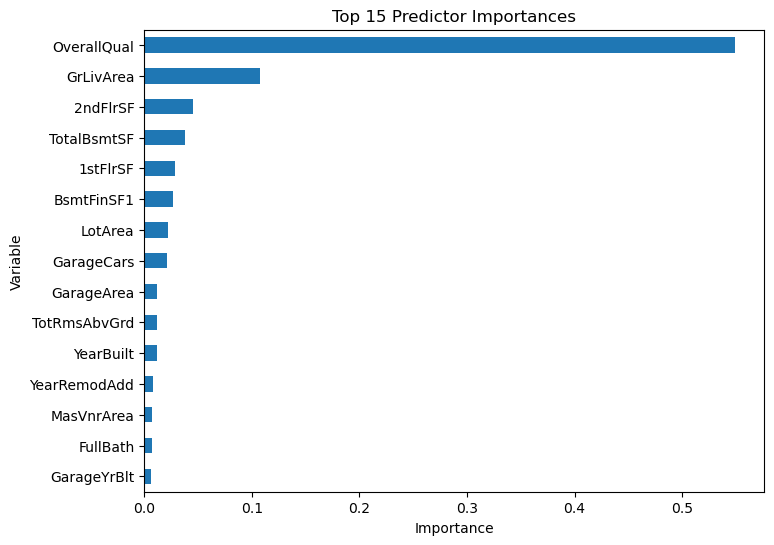

In [23]:

# TODO
top15 = importance_df.head(15).sort_values("Importance")
top15.plot(x="Variable", y="Importance", kind="barh", legend=False, figsize=(8,6))
plt.title("Top 15 Predictor Importances")
plt.xlabel("Importance")
plt.show()

## Practice 5C — Create reduced train and test matrices

In [25]:
importance_df.head(20)["Variable"].tolist()

['OverallQual',
 'GrLivArea',
 '2ndFlrSF',
 'TotalBsmtSF',
 '1stFlrSF',
 'BsmtFinSF1',
 'LotArea',
 'GarageCars',
 'GarageArea',
 'TotRmsAbvGrd',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'FullBath',
 'GarageYrBlt',
 'BsmtUnfSF',
 'LotFrontage',
 'OpenPorchSF',
 'OverallCond',
 'CentralAir_Y']

In [26]:

# TODO
top20_features = importance_df.head(20)["Variable"].tolist()
X_train_final = X_train[top20_features]
X_test_final = X_test[top20_features]

print("Original number of predictors:", None if X_train is None else X_train.shape[1])
print("Selected predictors:", None if X_train_final is None else X_train_final.shape[1])

Original number of predictors: 258
Selected predictors: 20


---

# 6. Feature Selection vs. PCA

Two different ideas:

### Feature selection
Keep a subset of the **original predictors**.

### PCA / feature extraction
Create new variables called **principal components** that summarize variation in the predictors.

PCA is **unsupervised** because it does not use `SalePrice`.

## Practice 6A — Quick PCA demonstration

We will run PCA only as a short demonstration, not as the main modeling path.

In [28]:
## PC1 = w1*x1 + w2*x2 + ....
## PC2 = w1*x1 + w2*x2 + .... (PC2 is UNCORRELATED to PC1)
## PREFERRED if variables are too correlated
## DRAWBACK: the variables are interpretable 

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Use training data only for fitting the scaler/PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(float))

pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_scaled)

print("PCA shape:", X_train_pca.shape)
print("Variance explained by each component:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

PCA shape: (1168, 3)
Variance explained by each component: [0.06721113 0.03296483 0.02888856]
Total variance explained: 0.1290645271800724


### Practice 6B — Compare the approaches

| Method | Uses target `y`? | Keeps original variable names? |
|---|---|---|
| Random-forest importance |  |  |
| PCA |  |  |

Which approach would usually be easier to explain to a real-estate manager? Why?

**Your response here:**  
-

---

# 7. Fit Candidate Models

We will compare three regression approaches:

- Linear Regression
- Random Forest
- Gradient Boosting

The goal here is not to master each algorithm yet. The goal is to understand the **modeling workflow**.

## Practice 7A — Fit the models (linear regression, RandomForest Regressor and GradientBoosting)

---

# 8. Make Predictions on Unseen Test Data

---

# 9. Evaluate and Compare Models

For regression:

### RMSE
Measures typical prediction error in dollars, while penalizing larger mistakes more strongly.

### MAE
Average absolute error in dollars.

### R²
The proportion of variation in `SalePrice` explained by the model.

In [ ]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



## Practice 9A — Choose a model

Using the results:

1. Which model has the lowest RMSE?
2. Which model has the highest R²?
3. What does the best RMSE mean in practical terms?
4. Does the lowest RMSE automatically mean that model should be deployed?

**Your response here:**  
1.  
2.  
3.  
4.

---

# 11. End-to-End Project Recap

Complete the table:

| Project Stage | What We Did |
|---|---|
| Define purpose |  |
| Obtain data |  |
| EDA |  |
| Handle data quality |  |
| Encode variables |  |
| Reduce/select features |  |
| Split data |  |
| Fit models |  |
| Evaluate models |  |
| Business recommendation |  |

---

# 12. Final Business Recommendation

You are presenting to a real-estate analytics manager.

Write a **3–4 sentence executive summary**:

1. What business problem did you address?
2. What model performed best?
3. How well did it perform?
4. What would you do before putting this model into production?

**Your response here:**  
-

## Exit ticket

What is the biggest difference between **fitting a machine-learning model** and completing an **end-to-end data mining project**?

**Your response here:**  
-